# Plot ETAN for entire domain

In [6]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
from scipy.stats import t
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [7]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:41219")
client

<Client: 'tcp://127.0.0.1:41219' processes=8 threads=32, memory=123.95 GiB>

In [8]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [9]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR dataset

In [10]:
# open ETAN zarr store - [psu]
ETAN_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/ETAN_AVG_DAILY.ZARR/', s3_options)

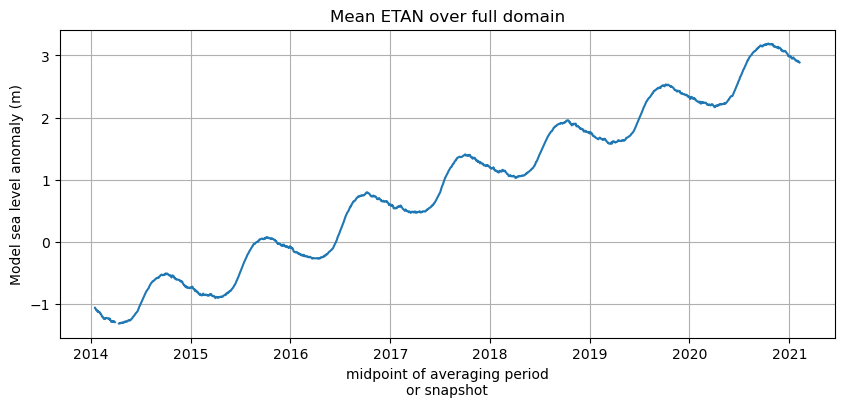

In [16]:
ETAN_zarr_day.ETAN.mean(dim=['j','i']).plot(figsize=[10,4]);
plt.grid()
plt.ylabel("Model sea level anomaly (m)")
plt.title('Mean ETAN over full domain');